In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import joblib
import shap

In [7]:
df= pd.read_csv('../data/Telco_Customer_Churn_Dataset.csv')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.shape

(7043, 21)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

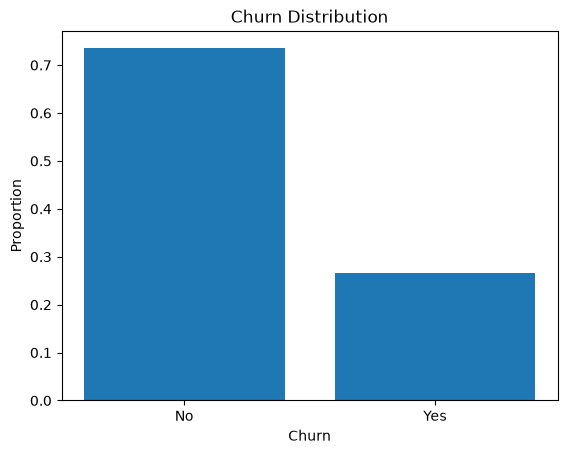

In [14]:
churn_counts = df['Churn'].value_counts(normalize=True)
plt.bar(x=churn_counts.index, height=churn_counts.values)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Proportion')
plt.show()

In [15]:
df.drop("customerID", axis=1, inplace=True)

In [16]:
# Convert numeric-looking column
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values created during conversion
df["TotalCharges"].isna().sum()

np.int64(11)

In [17]:
df[df['TotalCharges'].isnull()]['tenure'].unique()

array([0])

11 missing TotalCharges values all correspond to customers with tenure = 0

In [18]:
df = df.dropna(subset=['TotalCharges'])

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

C:\Users\navya\AppData\Local\Temp\ipykernel_20812\320214897.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


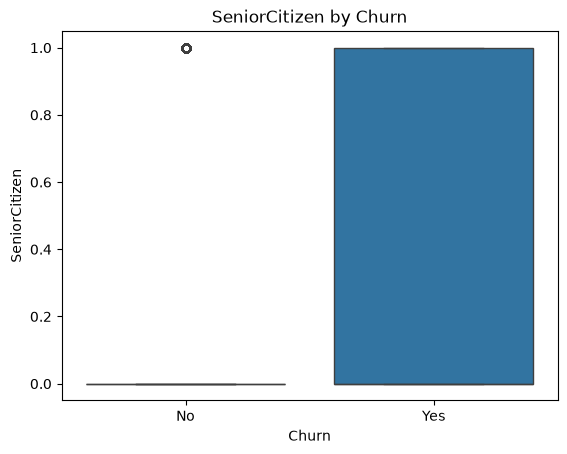

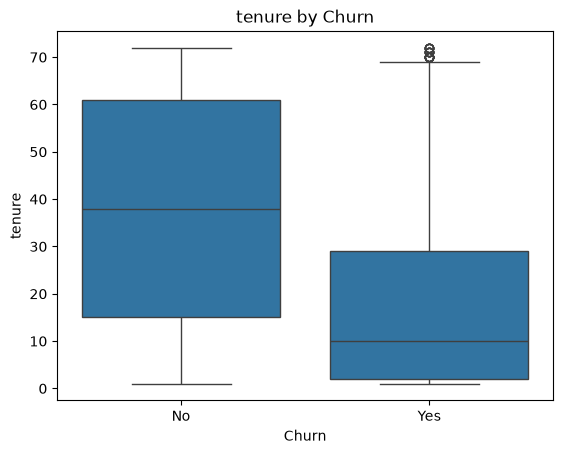

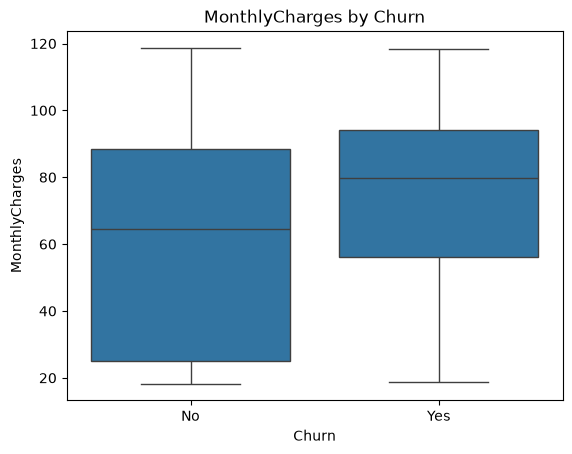

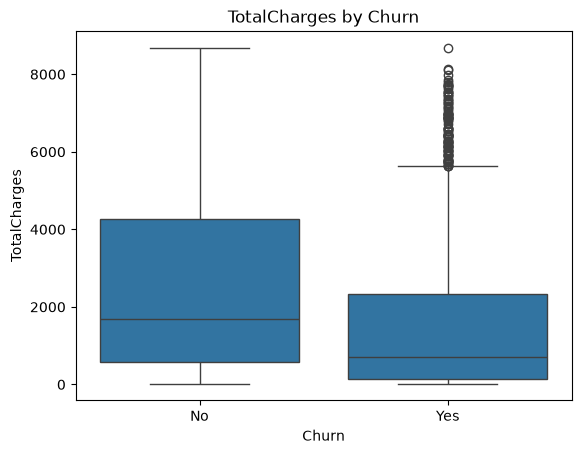

In [20]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} by Churn')
    plt.show()

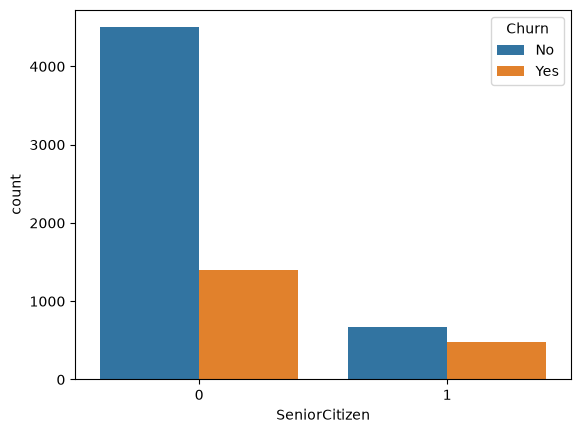

SeniorCitizen  Churn
0              No       0.763497
               Yes      0.236503
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

In [21]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.show()
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)

1. Since seniorcitizen is a binary variable it is better to plot a countplot for it than box plot
2. Tenure one shows new people are more likely to churn
3. People paying more monthly charges are more likely to churn
4. People paying lesser totalcharges are more likely to churn
5. Senior citizen are comparatively more likely to churn than non-senior citizen

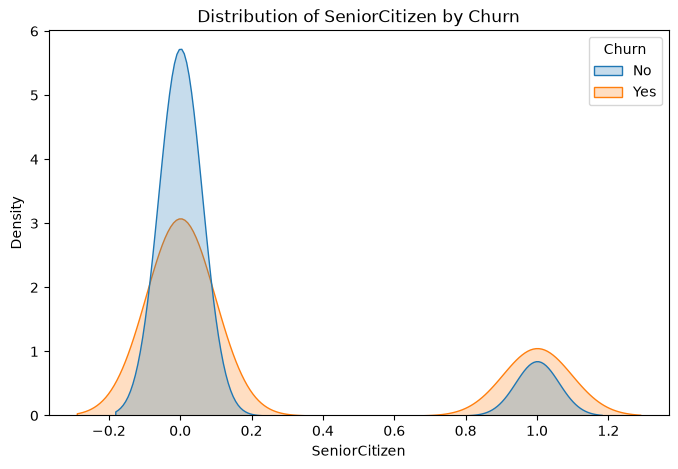

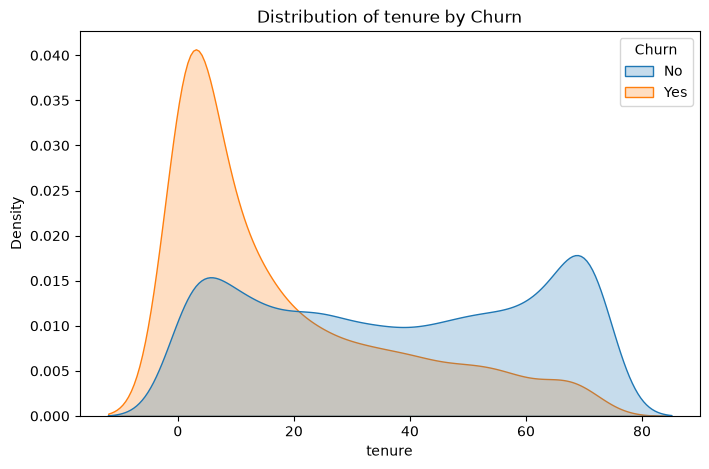

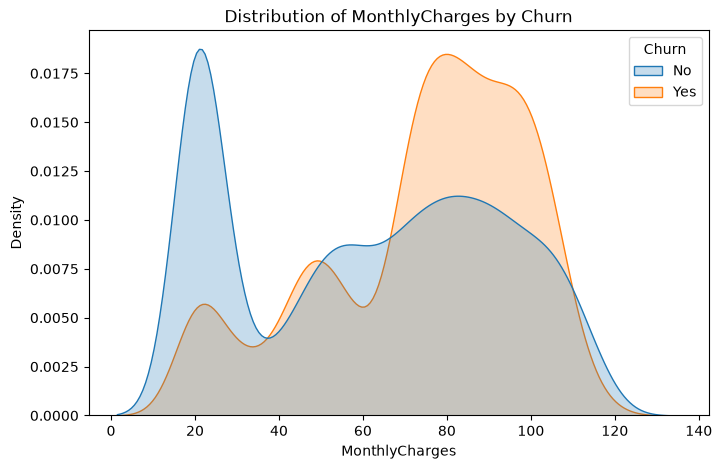

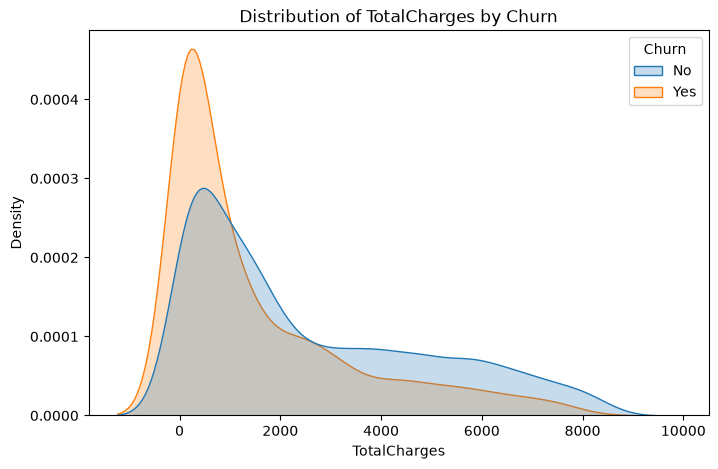

In [22]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(x=col, hue='Churn', data=df, fill=True, common_norm=False)
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

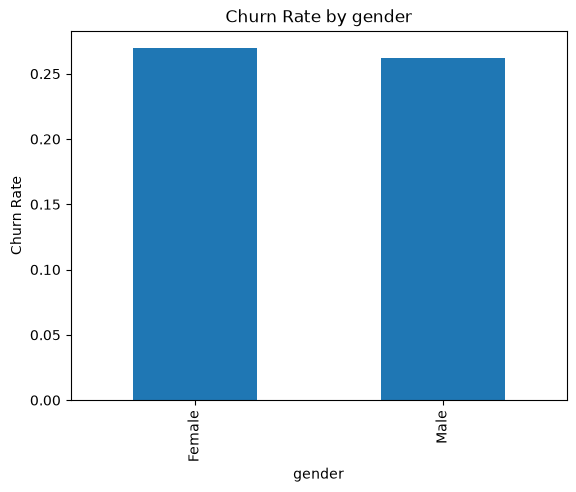

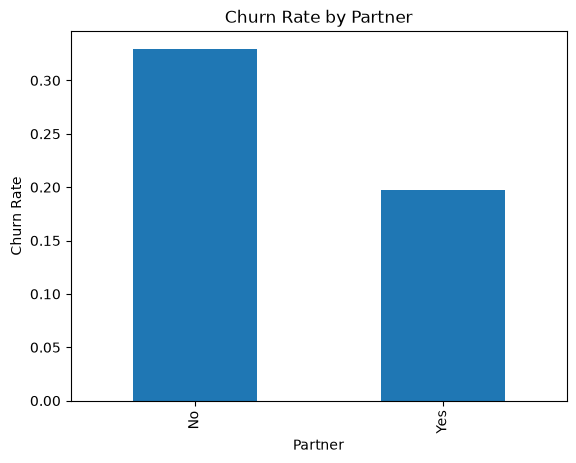

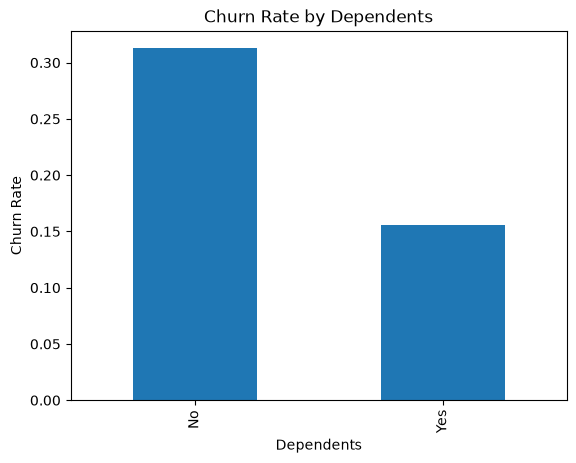

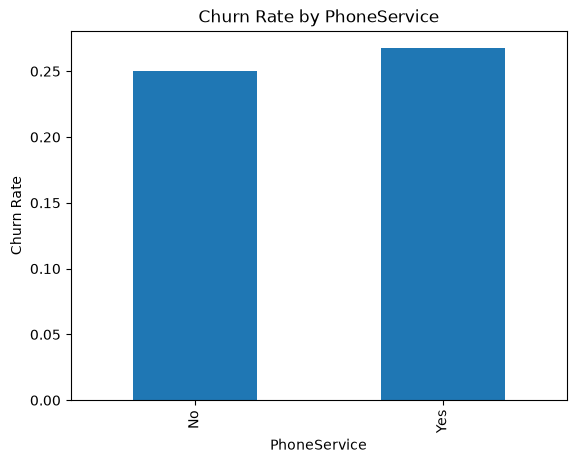

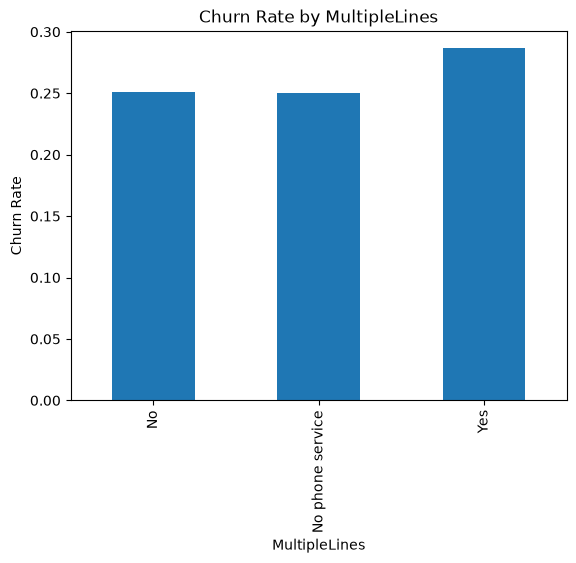

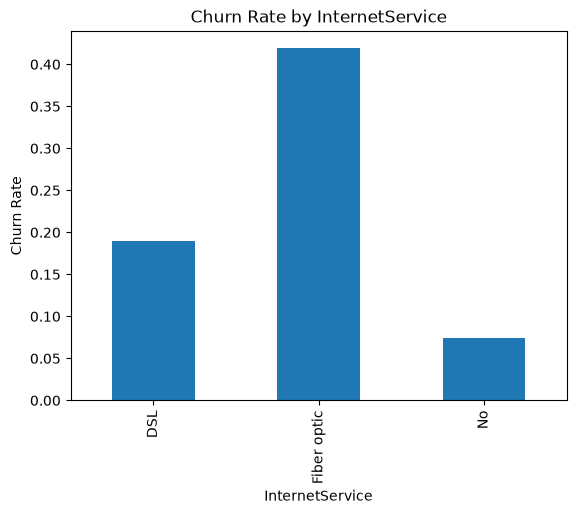

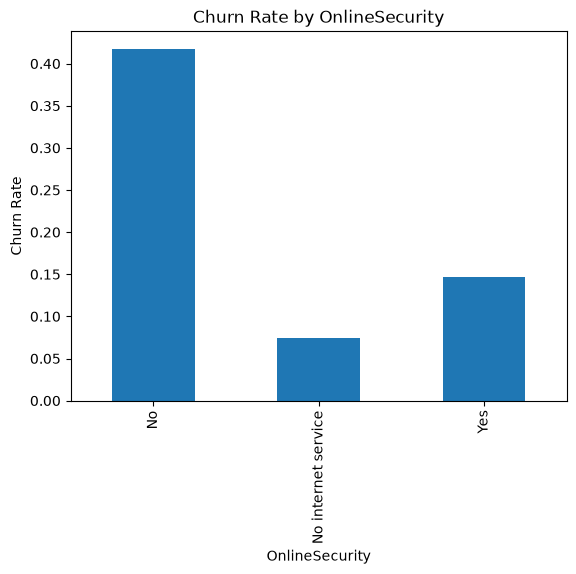

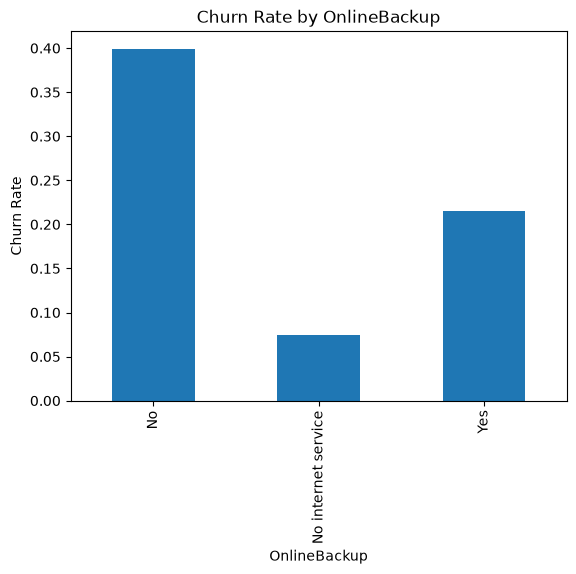

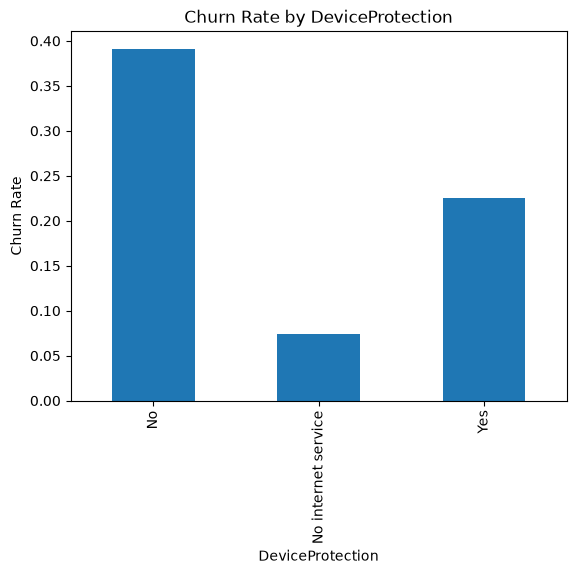

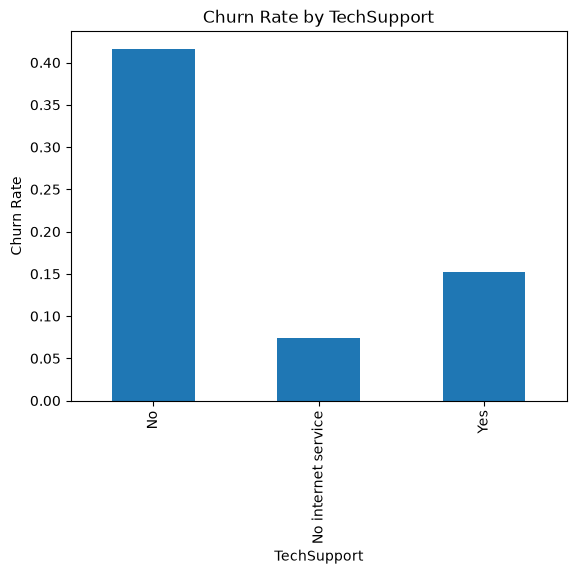

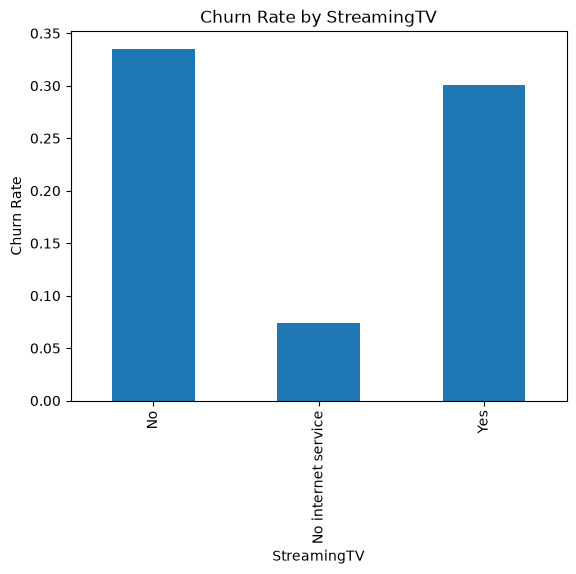

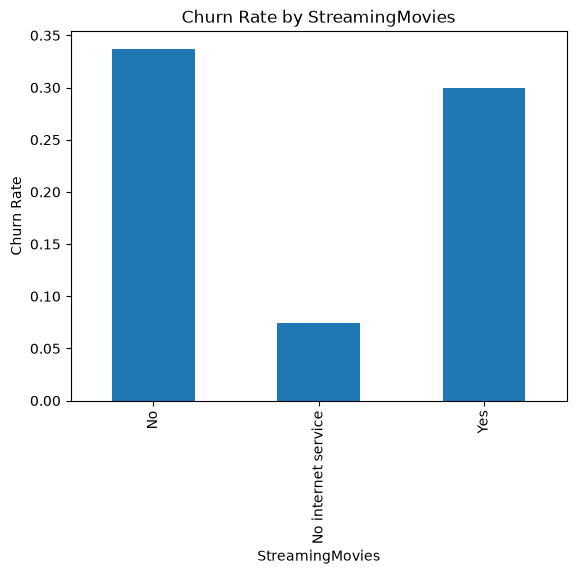

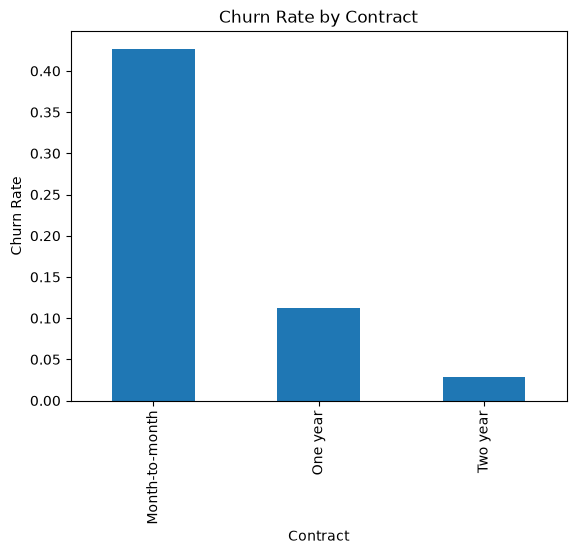

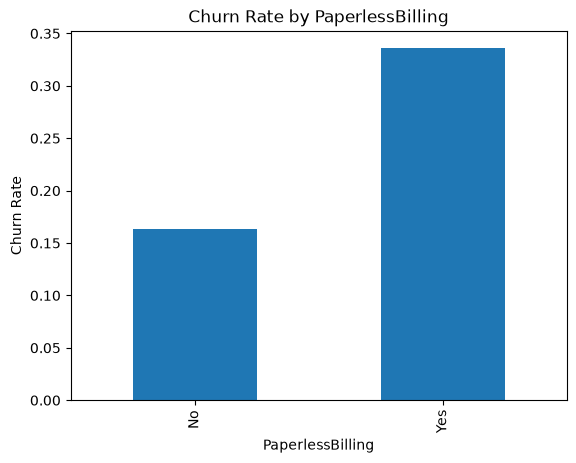

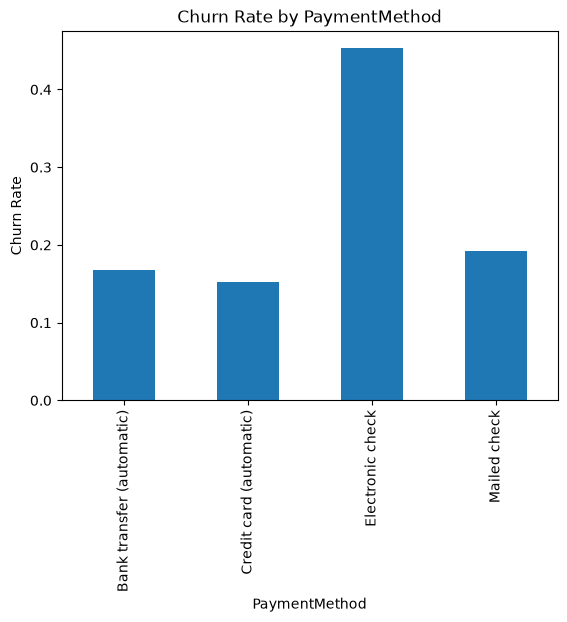

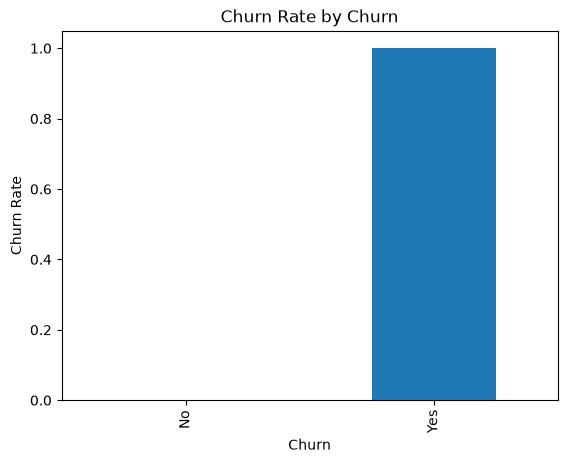

In [23]:
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.plot(kind='bar', title=f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.show()

In [24]:
# Feature Engineering Phase

In [25]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [26]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [27]:
# Binary Mapping
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

binary_map = {
    'gender': {'Male': 1, 'Female': 0},
    'Partner': {'Yes': 1, 'No': 0},
    'Dependents': {'Yes': 1, 'No': 0},
    'PhoneService': {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}

for col in binary_cols:
    X[col] = X[col].map(binary_map[col])

In [28]:
# Ordinal column, manual encoding
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
X['Contract'] = X['Contract'].map(contract_order)

In [29]:
# Nominal cols(ones with no order), will be one-hot encoded
nominal_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]

In [30]:
# Train-test split before fitting any encoder otherwise data leakage happens
# stratify=y because it is an imbalanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean(), "Test churn rate:", y_test.mean())

Train shape: (5625, 19) Test shape: (1407, 19)
Train churn rate: 0.2657777777777778 Test churn rate: 0.2658137882018479


In [31]:
# Building the preprocessing step
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols)
    ],
    remainder='passthrough'  # keeps binary + ordinal + numeric cols as-is
)

In [32]:
# Candidate models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric='logloss', random_state=42
    )
}

In [33]:
# Cross-validating each model
scoring = ['precision', 'recall', 'f1', 'average_precision', 'roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    results[name] = {
        metric: (cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std())
        for metric in scoring
    }

c:\Users\navya\Downloads\telco_churn\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\navya\Downloads\telco_churn\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

In [34]:
# Printing comparison table
comparison_df = pd.DataFrame({
    name: {metric: f"{vals[0]:.3f} (+/-{vals[1]:.3f})" for metric, vals in metrics.items()}
    for name, metrics in results.items()
}).T
print("\nModel Comparison (cross-validated):")
print(comparison_df)


Model Comparison (cross-validated):
                            precision            recall                f1  \
Logistic Regression  0.521 (+/-0.007)  0.803 (+/-0.015)  0.632 (+/-0.007)   
Random Forest        0.571 (+/-0.021)  0.643 (+/-0.024)  0.605 (+/-0.019)   
XGBoost              0.554 (+/-0.011)  0.658 (+/-0.025)  0.601 (+/-0.015)   

                    average_precision           roc_auc  
Logistic Regression  0.659 (+/-0.012)  0.846 (+/-0.006)  
Random Forest        0.622 (+/-0.022)  0.829 (+/-0.009)  
XGBoost              0.623 (+/-0.021)  0.824 (+/-0.011)  


Based on this comparison table Logistic Regression worked the best, it showed highest recall which is a very important evaluation metric in a telcom churn dataset as we need to correctly identify the churners.

In [35]:
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric='logloss', random_state=42
    ))
])

In [36]:
param_grid = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    xgb_pipe, param_grid, cv=cv, scoring='average_precision', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\nBest params:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)


Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV PR-AUC: 0.6659662249897648


In [37]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))



Test Set Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.75      1407

Test ROC-AUC: 0.83999021592268
Test PR-AUC: 0.6518886321582291


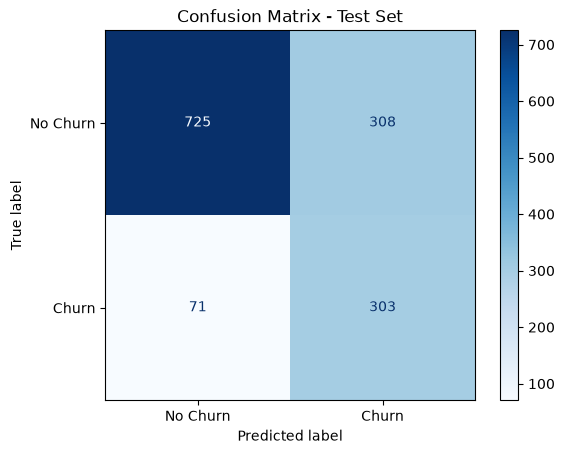

In [38]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

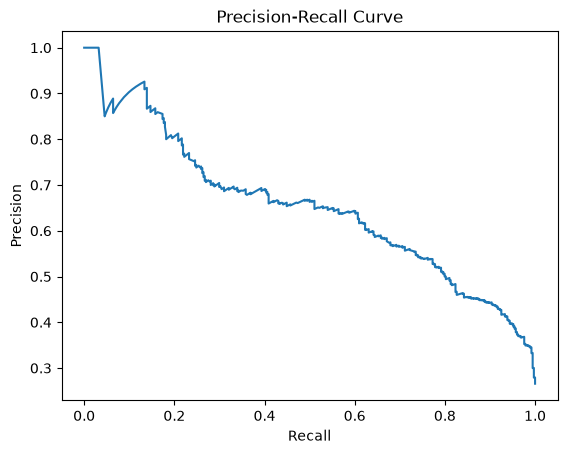

In [39]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [40]:
joblib.dump(best_model, 'churn_model_pipeline.pkl')
print("\nModel saved as churn_model_pipeline.pkl")


Model saved as churn_model_pipeline.pkl


In [41]:
# Isolating false pos and false neg
results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = y_pred
results_df['churn_probability'] = y_proba

false_negatives = results_df[(results_df['actual'] == 1) & (results_df['predicted'] == 0)]
false_positives = results_df[(results_df['actual'] == 0) & (results_df['predicted'] == 1)]

print(f"False Negatives (missed churners): {len(false_negatives)}")
print(f"False Positives (false alarms): {len(false_positives)}")

False Negatives (missed churners): 71
False Positives (false alarms): 308


In [42]:
print("\n--- Sample False Negatives ---")
print(false_negatives[['tenure', 'Contract', 'MonthlyCharges', 'churn_probability']].head(10))

print("\n--- Sample False Positives ---")
print(false_positives[['tenure', 'Contract', 'MonthlyCharges', 'churn_probability']].head(10))


--- Sample False Negatives ---
      tenure  Contract  MonthlyCharges  churn_probability
3721       2         0           20.65           0.359482
4653      30         0           51.20           0.336195
2300      48         1          103.25           0.414869
18        10         0           55.20           0.404729
2244      34         1           64.40           0.096748
2005      49         1          100.45           0.423732
1014      18         0           57.45           0.478821
5006      15         0           55.70           0.425195
3831      25         1           89.05           0.321700
654        8         0           19.65           0.360878

--- Sample False Positives ---
      tenure  Contract  MonthlyCharges  churn_probability
619        7         0           78.55           0.806787
4283       4         0           70.20           0.843974
6128      14         0           78.10           0.792198
5384       4         0           64.40           0.675317
559     

In [43]:
print("\n--- Tenure comparison ---")
print("False Negatives median tenure:", false_negatives['tenure'].median())
print("Overall test set median tenure:", X_test['tenure'].median())

print("\n--- Contract type comparison ---")
print("False Negatives contract distribution:")
print(false_negatives['Contract'].value_counts(normalize=True))
print("\nOverall test set contract distribution:")
print(X_test['Contract'].value_counts(normalize=True))


--- Tenure comparison ---
False Negatives median tenure: 38.0
Overall test set median tenure: 28.0

--- Contract type comparison ---
False Negatives contract distribution:
Contract
1    0.507042
0    0.380282
2    0.112676
Name: proportion, dtype: float64

Overall test set contract distribution:
Contract
0    0.561478
2    0.232409
1    0.206112
Name: proportion, dtype: float64


Model incorrectly predicted as non-churners tend to have higher
tenure.

Model particularly struggles to identify churners belonging to Contract = 1.

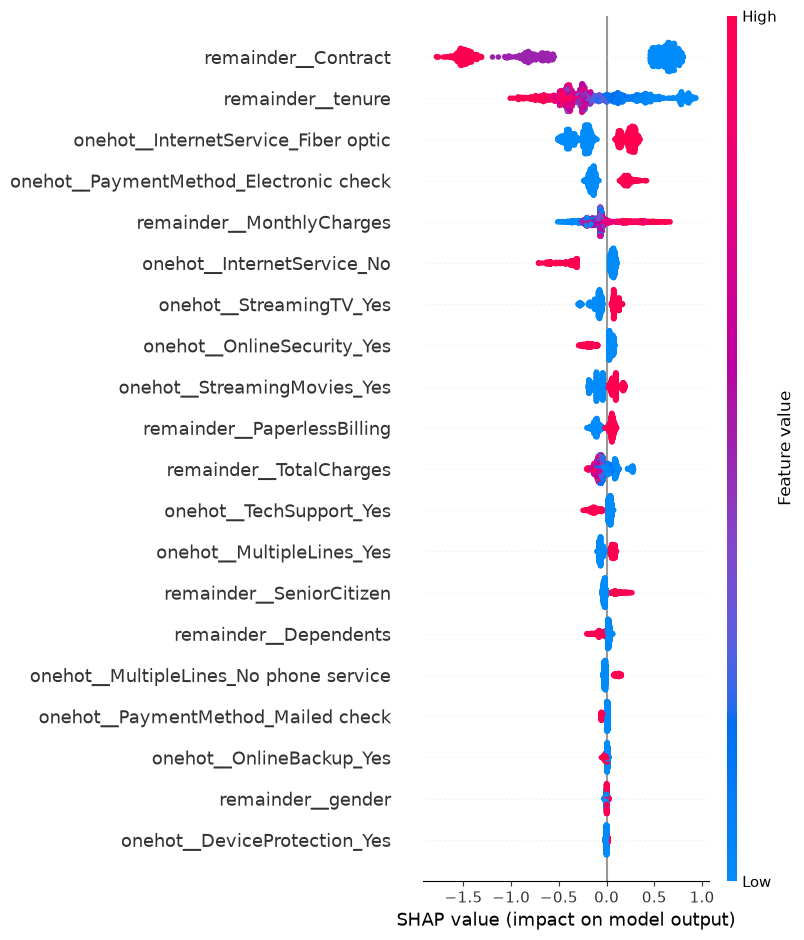

In [44]:
# shap
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_classifier = best_model.named_steps['classifier']

X_test_transformed = fitted_preprocessor.transform(X_test)

feature_names = fitted_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(fitted_classifier)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

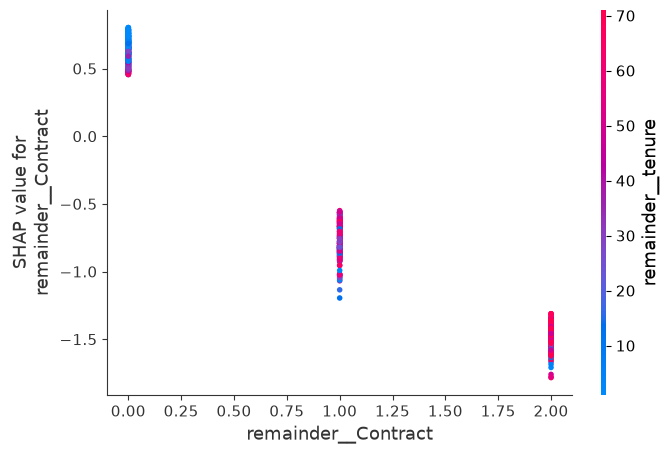

In [45]:
shap.dependence_plot('remainder__Contract', shap_values, X_test_transformed, feature_names=feature_names)

In [46]:
thresholds_to_try = [0.3, 0.4, 0.5, 0.6]
print("\n--- Performance at different thresholds ---")
for t in thresholds_to_try:
    preds_at_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, preds_at_t)
    r = recall_score(y_test, preds_at_t)
    f1 = f1_score(y_test, preds_at_t)
    print(f"Threshold {t}: Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")


--- Performance at different thresholds ---
Threshold 0.3: Precision=0.428, Recall=0.922, F1=0.585
Threshold 0.4: Precision=0.451, Recall=0.864, F1=0.593
Threshold 0.5: Precision=0.496, Recall=0.810, F1=0.615
Threshold 0.6: Precision=0.559, Recall=0.719, F1=0.629
